# MNIST Handwritten Digits Classification using Multi-Layer Perceptron (MLP)

## Objective

The objective of this notebook is to understand and classify handwritten digits using the **MNIST dataset**. The dataset contains **70,000 grayscale images** of handwritten digits (0–9), where each image has a size of **28 × 28 pixels**.

In this notebook, I will:
- Load the MNIST dataset from OpenML.
- Explore the dataset and visualize sample images.
- Understand pixel values and image representation.
- Scale pixel values from **0–255** to **0–1**.
- Train a Multi-Layer Perceptron (MLP) classifier.
- Evaluate the model using accuracy and a confusion matrix.
- Visualize incorrect predictions.
- Summarize the observations and compare the results with the smaller Digits dataset.

## Step 1: Load the MNIST Dataset

The MNIST dataset is loaded from **OpenML** using Scikit-learn's `fetch_openml()` function.

Unlike the Digits dataset, MNIST is not built into Scikit-learn and needs to be downloaded the first time it is used.

The dataset contains:
- **70,000 handwritten digit images**
- **28 × 28 pixels** per image
- **784 features** after flattening each image
- **10 classes** representing digits from **0 to 9**

In [3]:
from sklearn.datasets import fetch_openml

# Load the MNIST dataset
mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False
)

print("MNIST dataset loaded successfully!")

MNIST dataset loaded successfully!


## Step 2: Explore the Dataset

Before training the model, it is important to understand the structure of the dataset.

In this step, I will:
- Check the shape of the feature matrix.
- Check the shape of the target labels.
- Understand how each image is represented as numerical data.

In [5]:
# Separate features and labels
X = mnist.data
y = mnist.target

# Print dataset shapes
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (70000, 784)
Shape of y: (70000,)


## Step 3: Visualize Sample Images

The MNIST dataset stores each handwritten digit as a flattened array containing **784 pixel values**.

To display the images correctly, each array must be reshaped into its original **28 × 28** format.

In this step, I will visualize a few handwritten digit images along with their corresponding labels.

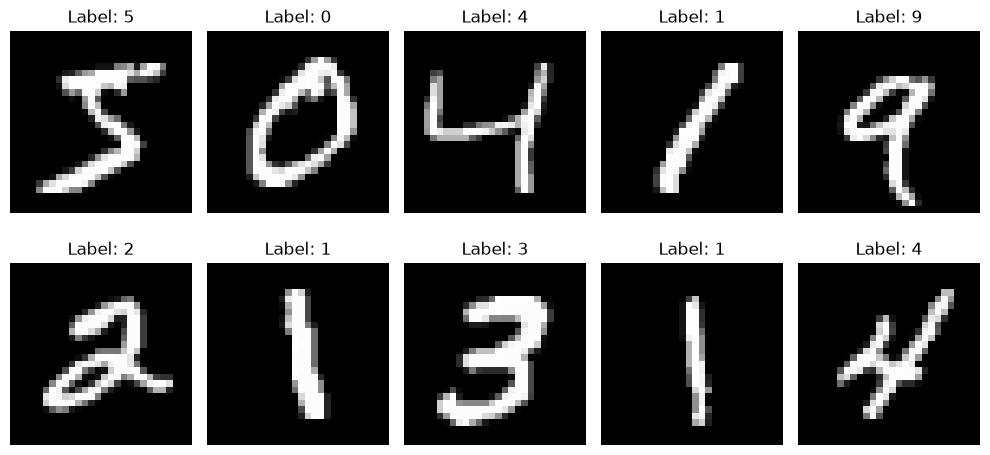

In [6]:
import matplotlib.pyplot as plt

# Display the first 10 handwritten digits
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Reshape 784 values into a 28x28 image
    plt.imshow(X[i].reshape(28, 28), cmap="gray")

    plt.title(f"Label: {y[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 4: Scale Pixel Values

The pixel values in the MNIST dataset range from **0 to 255** because the images are stored as 8-bit grayscale images.

Before training the neural network, the pixel values are scaled to the range **0 to 1** by dividing every pixel value by **255**.

Feature scaling helps the neural network train faster, improves numerical stability, and often leads to better model performance.

In [7]:
# Scale pixel values from 0-255 to 0-1

X_scaled = X / 255.0

print("Minimum pixel value:", X_scaled.min())
print("Maximum pixel value:", X_scaled.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Step 5: Split the Dataset

Before training the model, the dataset is divided into training and testing sets.

- The training set is used to train the neural network.
- The testing set is used to evaluate the model on unseen data.

In this experiment, the original (unscaled) dataset is used first so that its performance can later be compared with the scaled dataset.

In [8]:
from sklearn.model_selection import train_test_split

# Split the original dataset (without scaling)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape :", X_train.shape)
print("Testing data shape  :", X_test.shape)

Training data shape : (56000, 784)
Testing data shape  : (14000, 784)


## Step 6: Train the MLP Classifier (Without Scaling)

The best-performing MLP configuration from the previous task is used to train the model on the original MNIST dataset without scaling.

The training time is also recorded because the MNIST dataset is much larger than the Digits dataset.

In [13]:
import time
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Best model from Day 3
mlp_unscaled = MLPClassifier(
    hidden_layer_sizes=(32,),
    max_iter=15,
    random_state=42,
    early_stopping=True
)

# Record training start time
start_time = time.time()

# Train the model
mlp_unscaled.fit(X_train, y_train)

# Record training end time
end_time = time.time()

training_time_unscaled = end_time - start_time

# Predictions
y_pred_unscaled = mlp_unscaled.predict(X_test)

# Accuracy
accuracy_unscaled = accuracy_score(y_test, y_pred_unscaled)

print(f"Training Time : {training_time_unscaled:.2f} seconds")
print(f"Testing Accuracy : {accuracy_unscaled:.4f}")

Training Time : 10.95 seconds
Testing Accuracy : 0.9252


/home/sabreen_rashid/miniconda3/envs/ml-intern/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(


## Step 6: Train MLP on Scaled MNIST Dataset

In this step, the same MLP architecture is trained on the scaled MNIST dataset. The goal is to compare the effect of feature scaling on model performance, convergence speed, and training time.

In [14]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import time

# Split the scaled dataset
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Create the MLP model
mlp_scaled = MLPClassifier(
    hidden_layer_sizes=(32,),
    max_iter=15,
    random_state=42
)

# Record training start time
start_time = time.time()

# Train the model
mlp_scaled.fit(X_train_scaled, y_train_scaled)

# Record training end time
end_time = time.time()

training_time_scaled = end_time - start_time

# Predictions
y_pred_scaled = mlp_scaled.predict(X_test_scaled)

# Accuracy
accuracy_scaled = accuracy_score(y_test_scaled, y_pred_scaled)

print(f"Training Time : {training_time_scaled:.2f} seconds")
print(f"Testing Accuracy : {accuracy_scaled:.4f}")

Training Time : 11.49 seconds
Testing Accuracy : 0.9623


/home/sabreen_rashid/miniconda3/envs/ml-intern/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(


## Observations: Effect of Feature Scaling

The MLP model was trained on the MNIST dataset both with and without feature scaling.

| Dataset | Training Time (s) | Test Accuracy | Convergence Warning |
|---------|------------------:|--------------:|--------------------|
| Without Scaling | 10.95 | 92.52% | Yes |
| With Scaling | 11.49 | 96.23% | Yes |

### Key Observations

- Scaling the pixel values from **0–255** to **0–1** significantly improved the model's test accuracy.
- The training time remained almost the same for both experiments.
- Both models displayed a convergence warning because the maximum number of iterations was limited to **15**.
- The convergence warning is expected because the maximum number of iterations was intentionally limited to 15. Despite this limitation, the scaled model achieved noticeably higher accuracy, demonstrating the importance of preprocessing.
- The scaled model learned more effectively within the same number of iterations, demonstrating why preprocessing is an important step when training neural networks.

## Step 7: Confusion Matrix

A confusion matrix is used to evaluate the performance of the classification model. It shows how many images were correctly classified and where the model made mistakes.

The diagonal values represent correct predictions, while the off-diagonal values represent misclassified digits.

<Figure size 800x800 with 0 Axes>

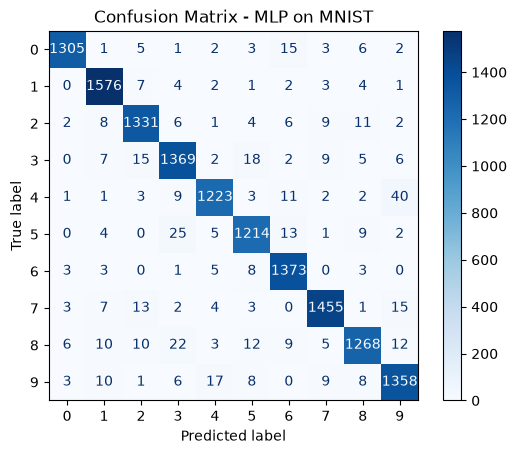

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test_scaled, y_pred_scaled)

# Display confusion matrix
plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix - MLP on MNIST")
plt.show()

## Observations from the Confusion Matrix

The confusion matrix provides a detailed summary of the model's classification performance across all digit classes.

### Observations

- Most predictions are concentrated along the **main diagonal**, indicating that the MLP classifier correctly identifies the majority of handwritten digits.
- Only a small number of values appear outside the diagonal, showing that the model makes relatively few misclassifications.
- Some digits are occasionally confused with visually similar digits, such as:
  - **0 and 6**
  - **3 and 5**
  - **4 and 9**
  - **7 and 9**
- These misclassifications mainly occur because handwritten digits can vary significantly in writing style, shape, and stroke thickness.
- Overall, the confusion matrix confirms that the MLP classifier performs well on the MNIST dataset, achieving high classification accuracy while making only a limited number of errors.

## Step 8: Visualizing Misclassified Images

Although the MLP classifier achieves high accuracy, it still makes a few incorrect predictions.

Visualizing these misclassified images helps us understand which digits are difficult for the model to classify correctly and identify patterns in its mistakes.

In [16]:
import numpy as np

# Find indices of incorrect predictions
wrong_indices = np.where(y_pred_scaled != y_test_scaled)[0]

print("Total Misclassified Images:", len(wrong_indices))

Total Misclassified Images: 528


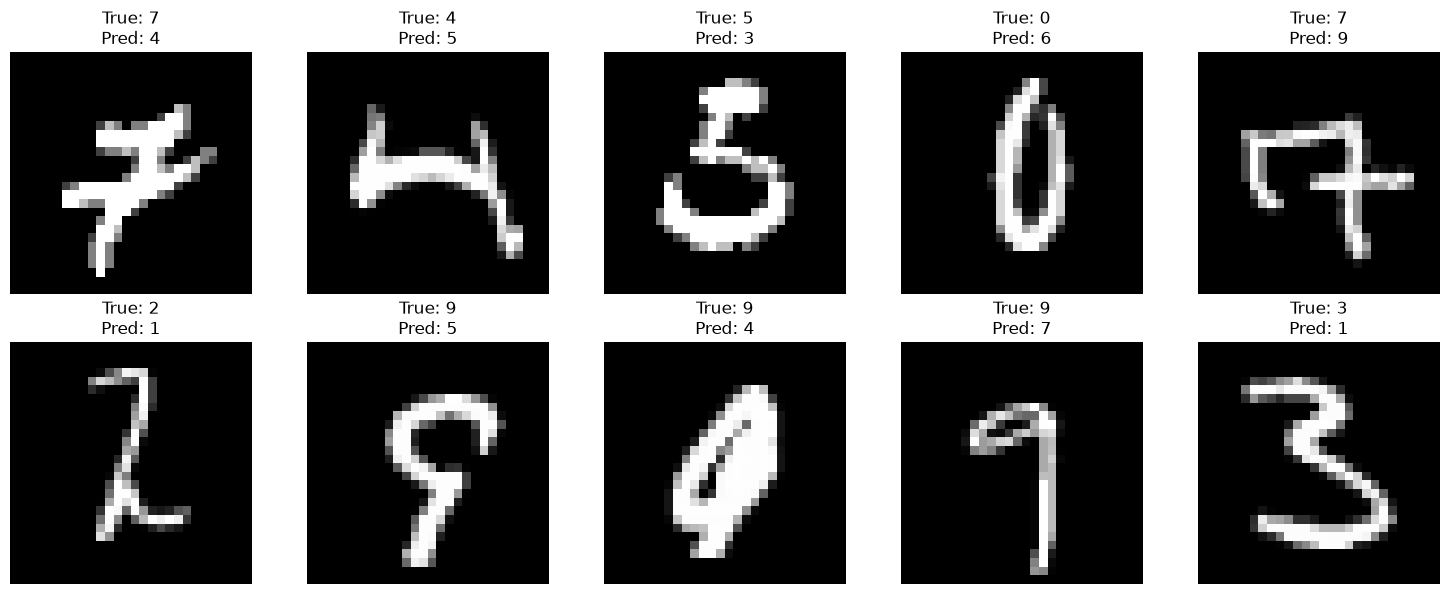

In [17]:
plt.figure(figsize=(15, 6))

for i, index in enumerate(wrong_indices[:10]):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test_scaled[index].reshape(28, 28),
               cmap="gray")

    plt.title(f"True: {y_test_scaled[index]}\nPred: {y_pred_scaled[index]}")

    plt.axis("off")

plt.tight_layout()
plt.show()

## Observations from Misclassified Images

The model incorrectly classified 528 images out of the test set.

After examining several misclassified samples, it is evident that most errors occur when handwritten digits are ambiguous, incomplete, or resemble other digits. Common confusions include digits such as 3 and 5, 4 and 9, 7 and 9, and 0 and 6.

These mistakes highlight the challenges of recognizing handwritten digits with varying writing styles. Despite these errors, the MLP classifier achieves strong overall performance, indicating that it generalizes well on the MNIST dataset.

# Final Write-up

## Final Results

- **Dataset:** MNIST Handwritten Digits
- **Total Images:** 70,000
- **Image Size:** 28 × 28 pixels
- **Best Model:** MLP Classifier (32 hidden neurons)
- **Testing Accuracy (Without Scaling):** **92.52%**
- **Testing Accuracy (With Scaling):** **96.23%**
- **Total Misclassified Images:** **528**

---

## What Changed Compared to the Small Digits Dataset?

Compared to the previous Digits dataset (1,797 images with 8×8 resolution), the MNIST dataset was significantly larger and more challenging.

### Key Differences

- The dataset size increased from **1,797** images to **70,000** images.
- Image resolution increased from **8×8 (64 features)** to **28×28 (784 features)**.
- Training took longer because the model had to process much more data.
- Pixel values ranged from **0–255**, making feature scaling necessary before training.
- Scaling the input data improved the testing accuracy from **92.52%** to **96.23%**.
- The confusion matrix and misclassified images showed that most prediction